# 실습 20: 얼마나 빗나갔나 (회귀)

설비 고장 기록으로 공정온도를 맞혀 본다

## Step 1. 데이터 확인

In [1]:
import pandas as pd

df = pd.read_csv("../../data/16_machine-failure.csv")

print("전체 행 수:", len(df))
print("열 개수:", df.shape[1])
print()
print("열 이름:", list(df.columns))
print()

숫자열 = df.select_dtypes(include="number").columns
print(df[숫자열].agg(["min", "max", "mean"]).T)


전체 행 수: 10000
열 개수: 7

열 이름: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']

                            min     max        mean
Air temperature [K]       295.3   304.5   300.00493
Process temperature [K]   305.7   313.8   310.00556
Rotational speed [rpm]   1168.0  2886.0  1538.77610
Torque [Nm]                 3.8    76.6    39.98691
Tool wear [min]             0.0   253.0   107.95100


## Step 2. 맞힐 숫자 정하기

맞힐 것 : Process temperature [K] - 공정온도
왜 : 지금 조건에서 나와야 할 온도를 알면, 실제가 그보다 높을 때 이상 신호가 된다

### 문법 노트 - 회귀에서 새로 나오는 이름

| 쓴 것 | 하는 일 |
|---|---|
| mean_absolute_error | 평균 몇 만큼 빗나갔나 (MAE) |
| mean_squared_error | 제곱해서 평균 - 뿌리를 씌우면 RMSE |
| r2_score | 기준 모델 대비 얼마나 나은가 (R2) |
| LinearRegression | 숫자를 맞히는 모델 중 가장 단순한 것 |

## Step 3. 한 바퀴 돌리기

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

입력열 = ["Air temperature [K]", "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]
X = df[입력열]
y = df["Process temperature [K]"]

# 1. 학습용/시험용 8:2로 나눈다
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. 기준 모델 - 늘 학습용 평균값을 답한다
기준예측 = np.full(len(y_test), y_train.mean())

# 3. 선형회귀 모델 학습
모델 = LinearRegression()
모델.fit(X_train, y_train)

# 4. 시험용으로 예측하고 나란히 비교
예측 = 모델.predict(X_test)

비교표 = pd.DataFrame({
    "기준 모델": [
        mean_absolute_error(y_test, 기준예측),
        mean_squared_error(y_test, 기준예측) ** 0.5,
        r2_score(y_test, 기준예측),
    ],
    "내 모델": [
        mean_absolute_error(y_test, 예측),
        mean_squared_error(y_test, 예측) ** 0.5,
        r2_score(y_test, 예측),
    ],
}, index=["MAE", "RMSE", "R2(제곱)"])

비교표


,기준 모델,내 모델
MAE,1.229517,0.595020
RMSE,1.472685,0.727922
R2(제곱),-0.000003,0.755684


위의 표 설명) 

- 기준 모델(80% 데이터의 평균값만 답하는, 학습하지 않은 모델)과
내 모델(80% 데이터로 실제 학습시킨 선형회귀 모델)을 만들어서,
20% 남겨둔 시험용 데이터로 각각 예측해서 얻은 값

## Step 4. 무엇을 보고 맞혔나

Torque [Nm]              -0.024444
Rotational speed [rpm]   -0.017912
Tool wear [min]          -0.004164
Air temperature [K]       1.304745
dtype: float64


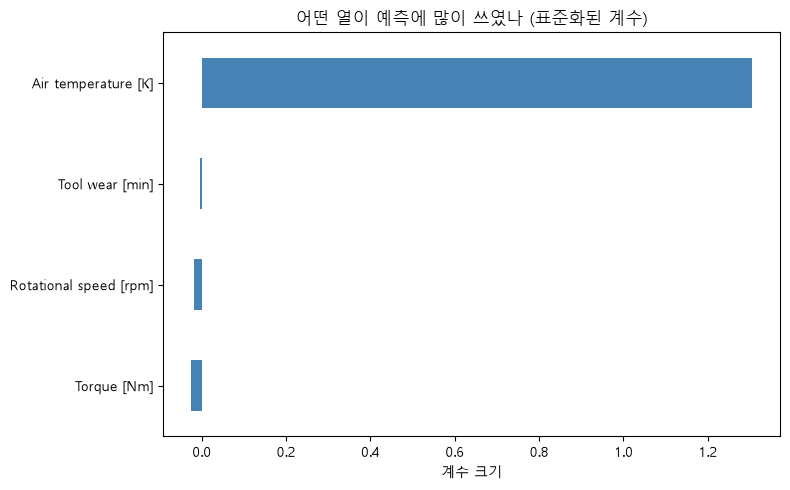

저장 위치: C:\Users\정유진\Desktop\secom-project\day07\lab20_regression\results\coefficients.png


In [3]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

# 한글이 깨지지 않도록 폰트를 먼저 잡는다 (Windows 기본 한글 폰트)
mpl.rcParams["font.family"] = "Malgun Gothic"
mpl.rcParams["axes.unicode_minus"] = False

# 열마다 단위·크기가 달라(rpm은 수천, 토크는 수십) 원래 계수를 그냥 비교하면 안 된다
# 입력을 표준화한 뒤 같은 모양의 모델을 하나 더 학습시켜 계수 크기로 비교한다
스케일러_회귀 = StandardScaler()
X_train_스케일 = 스케일러_회귀.fit_transform(X_train)

모델_표준화 = LinearRegression()
모델_표준화.fit(X_train_스케일, y_train)

계수 = pd.Series(모델_표준화.coef_, index=입력열).sort_values()
print(계수)

fig, ax = plt.subplots(figsize=(8, 5))
계수.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("어떤 열이 예측에 많이 쓰였나 (표준화된 계수)")
ax.set_xlabel("계수 크기")
fig.tight_layout()

os.makedirs("results", exist_ok=True)
저장경로 = os.path.join("results", "coefficients.png")
fig.savefig(저장경로, dpi=150, bbox_inches="tight")
plt.show()

print("저장 위치:", os.path.abspath(저장경로))


---
## [직접 해보기 (도전) - 대상을 바꾸면 자도 바뀐다]

- 상황: 공정온도는 잘 맞혔는데, 다른 값도 같은 방식으로 되나
- 할 일: 맞히는 대상을 토크로 바꿔 한 번 더 돌리고 두 결과를 나란히 놓는다
- 결과물: 여섯 칸짜리 비교표 1개

In [4]:
# 도전: 이번에는 토크(Torque [Nm])를 맞혀본다
입력열_토크 = ["Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]", "Tool wear [min]"]  # 입력 열 (토크 자신은 뺀다)
X_토크 = df[입력열_토크]  # 입력
y_토크 = df["Torque [Nm]"]  # 맞힐 값 - 토크

# 1. 학습용/시험용 8:2로 나눈다 (공정온도와 같은 방식)
X_train_토크, X_test_토크, y_train_토크, y_test_토크 = train_test_split(
    X_토크, y_토크, test_size=0.2, random_state=42
)

# 2. 기준 모델 - 늘 학습용 평균값을 답한다
기준예측_토크 = np.full(len(y_test_토크), y_train_토크.mean())

# 3. 선형회귀 모델 학습
모델_토크 = LinearRegression()
모델_토크.fit(X_train_토크, y_train_토크)

# 4. 시험용으로 예측하고 나란히 비교
예측_토크 = 모델_토크.predict(X_test_토크)

비교표_토크 = pd.DataFrame({
    "기준 모델": [
        mean_absolute_error(y_test_토크, 기준예측_토크),
        mean_squared_error(y_test_토크, 기준예측_토크) ** 0.5,
        r2_score(y_test_토크, 기준예측_토크),
    ],
    "내 모델": [
        mean_absolute_error(y_test_토크, 예측_토크),
        mean_squared_error(y_test_토크, 예측_토크) ** 0.5,
        r2_score(y_test_토크, 예측_토크),
    ],
}, index=["MAE", "RMSE", "R2(제곱)"])

비교표_토크


,기준 모델,내 모델
MAE,7.905037,3.686211
RMSE,9.928055,4.897887
R2(제곱),-0.000111,0.756591


In [5]:
# 공정온도 모델과 토크 모델의 "내 모델" 결과만 나란히 놓는다
비교표_최종 = pd.DataFrame({
    "공정온도": [
        mean_absolute_error(y_test, 예측),
        mean_squared_error(y_test, 예측) ** 0.5,
        r2_score(y_test, 예측),
    ],
    "토크": [
        mean_absolute_error(y_test_토크, 예측_토크),
        mean_squared_error(y_test_토크, 예측_토크) ** 0.5,
        r2_score(y_test_토크, 예측_토크),
    ],
}, index=["MAE", "RMSE", "R2"])

비교표_최종


,공정온도,토크
MAE,0.595020,3.686211
RMSE,0.727922,4.897887
R2,0.755684,0.756591


In [6]:
import os
print(os.getcwd())    # getcwd = 지금 작업 중인 폴더

C:\Users\정유진\Desktop\secom-project\day07\lab20_regression
